# 05. Modelado de clustering: K-Means y DBSCAN (Persona 5)

## 🇪🇸 Objetivo

Entrenar y comparar dos modelos de clustering no supervisado sobre el dataset
`celda x features` (ya reducido con PCA por Persona 4) para segmentar las
celdas H3 globales en perfiles de riesgo geologico:

- **K-Means**: segmentacion limpia en K grupos, usando metodo del codo +
  coeficiente de Silhouette para elegir K.
- **DBSCAN**: clustering basado en densidad, ejecutado en paralelo. Las
  celdas que caen como "ruido" no se descartan: se tratan explicitamente
  como senal de riesgo atipico real (una combinacion rara y extrema de
  peligros que no encaja en ningun grupo denso).

Al final se comparan ambos modelos y se justifica cual queda como modelo
principal para el producto, dejando el dataset de labels listo para que
Persona 6 haga las pruebas de estabilidad y los 4 casos de estudio.

---

# 05. Clustering modeling: K-Means and DBSCAN (Person 5)

## 🇬🇧 Objective

Train and compare two unsupervised clustering models on the `cell x
features` dataset (already PCA-reduced by Person 4) to segment the global
H3 cells into geological risk profiles:

- **K-Means**: a clean K-way segmentation, using the elbow method +
  Silhouette coefficient to pick K.
- **DBSCAN**: density-based clustering, run in parallel. Cells that fall
  out as "noise" are not discarded: they're explicitly treated as a signal
  of real atypical risk (a rare, extreme combination of hazards that
  doesn't fit any dense group).

At the end, both models are compared and a written justification is given
for which one becomes the primary product model, leaving the labeled
dataset ready for Person 6's stability tests and the 4 case studies.

In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CURRENT_DIRECTORY = Path.cwd()
PROJECT_ROOT = CURRENT_DIRECTORY if (CURRENT_DIRECTORY / "src").exists() else CURRENT_DIRECTORY.parent

import sys
sys.path.append(str(PROJECT_ROOT))

from src.clustering import (
    compute_elbow,
    compute_silhouette_by_k,
    find_knee_point,
    fit_kmeans,
    k_distance_values,
    suggest_eps,
    fit_dbscan,
    cluster_summary,
    silhouette_excluding_noise,
)
from src.visualization import (
    plot_elbow,
    plot_silhouette_by_k,
    plot_kdistance,
    plot_pca_2d,
    plot_cluster_map,
)

pd.set_option("display.max_columns", None)
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f"[ES] Raiz del proyecto: {PROJECT_ROOT}")
print(f"[EN] Project root: {PROJECT_ROOT}")

[ES] Raiz del proyecto: c:\Users\jowel\OneDrive\Escritorio\Bootcamp\GeoRisk_Finder
[EN] Project root: c:\Users\jowel\OneDrive\Escritorio\Bootcamp\GeoRisk_Finder


## 1. 🇪🇸 Carga de datos

`dataset_pca.csv` (componentes principales, salida de Persona 4) y
`grid_features.csv` (features crudas por celda, con `cell_id`/`lat`/`lon`)
comparten el mismo orden de filas — ambos se generan a partir de
`load_combined_data()` sin reordenar ni descartar filas — asi que se pueden
unir por posicion sin necesidad de una clave explicita.

---

## 1. 🇬🇧 Data loading

`dataset_pca.csv` (principal components, Person 4's output) and
`grid_features.csv` (raw per-cell features, with `cell_id`/`lat`/`lon`)
share the exact same row order — both are generated from
`load_combined_data()` without reordering or dropping any rows — so they
can be joined by position without needing an explicit key.

In [5]:
df_pca = pd.read_csv(PROJECT_ROOT / "notebooks" / "data" / "processed" / "dataset_pca.csv")
df_grid = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "grid_features.csv")

assert len(df_pca) == len(df_grid), "Row count mismatch between dataset_pca.csv and grid_features.csv"

pc_cols = [c for c in df_pca.columns if c.startswith("PC")]
X = df_pca[pc_cols].values

df_cells = pd.concat(
    [df_grid[["cell_id", "lat", "lon"]].reset_index(drop=True), df_pca.reset_index(drop=True)],
    axis=1,
)

print(f"[ES] Celdas: {len(df_cells):,} | Componentes principales: {pc_cols}")
print(f"[EN] Cells: {len(df_cells):,} | Principal components: {pc_cols}")
df_cells.head()

[ES] Celdas: 41,162 | Componentes principales: ['PC1', 'PC2', 'PC3', 'PC4']
[EN] Cells: 41,162 | Principal components: ['PC1', 'PC2', 'PC3', 'PC4']


,cell_id,lat,lon,PC1,PC2,PC3,PC4
0,830d83fffffffff,66.541996,-175.333902,2.558660,-2.607008,-0.809499,0.975908
1,832969fffffffff,34.792390,-136.442913,-1.567276,-1.237486,-0.071005,0.428197
2,83722efffffffff,6.739360,138.817498,-0.244111,3.009657,0.208280,-0.643323
3,8314b1fffffffff,48.255967,125.684028,-1.410689,-0.981030,0.405757,-1.177764
4,836803fffffffff,6.893151,117.880300,4.030146,0.675389,-0.299639,-1.067362


## 2. 🇪🇸 K-Means — seleccion de K

Se combinan dos criterios sobre el mismo rango de K:

- **Metodo del codo**: inercia (WCSS) vs K. Se detecta el "codo" con la
  heuristica estandar de maxima distancia a la cuerda entre el primer y
  ultimo punto de la curva (Satopaa et al., el mismo principio que usa
  la libreria `kneed`).
- **Coeficiente de Silhouette**: se calcula sobre una muestra de 5,000
  celdas (con semilla fija) para que sea tratable con >40k celdas, y se
  usa como criterio principal de calidad de separacion entre clusters.

---

## 2. 🇬🇧 K-Means — choosing K

Two criteria are combined over the same range of K:

- **Elbow method**: inertia (WCSS) vs. K. The "elbow" is detected with the
  standard maximum-distance-to-chord heuristic between the curve's first
  and last points (Satopaa et al., the same principle behind the `kneed`
  library).
- **Silhouette coefficient**: computed on a fixed-seed sample of 5,000
  cells so it stays tractable with >40k cells, and used as the main
  quality criterion for how well-separated the clusters are.

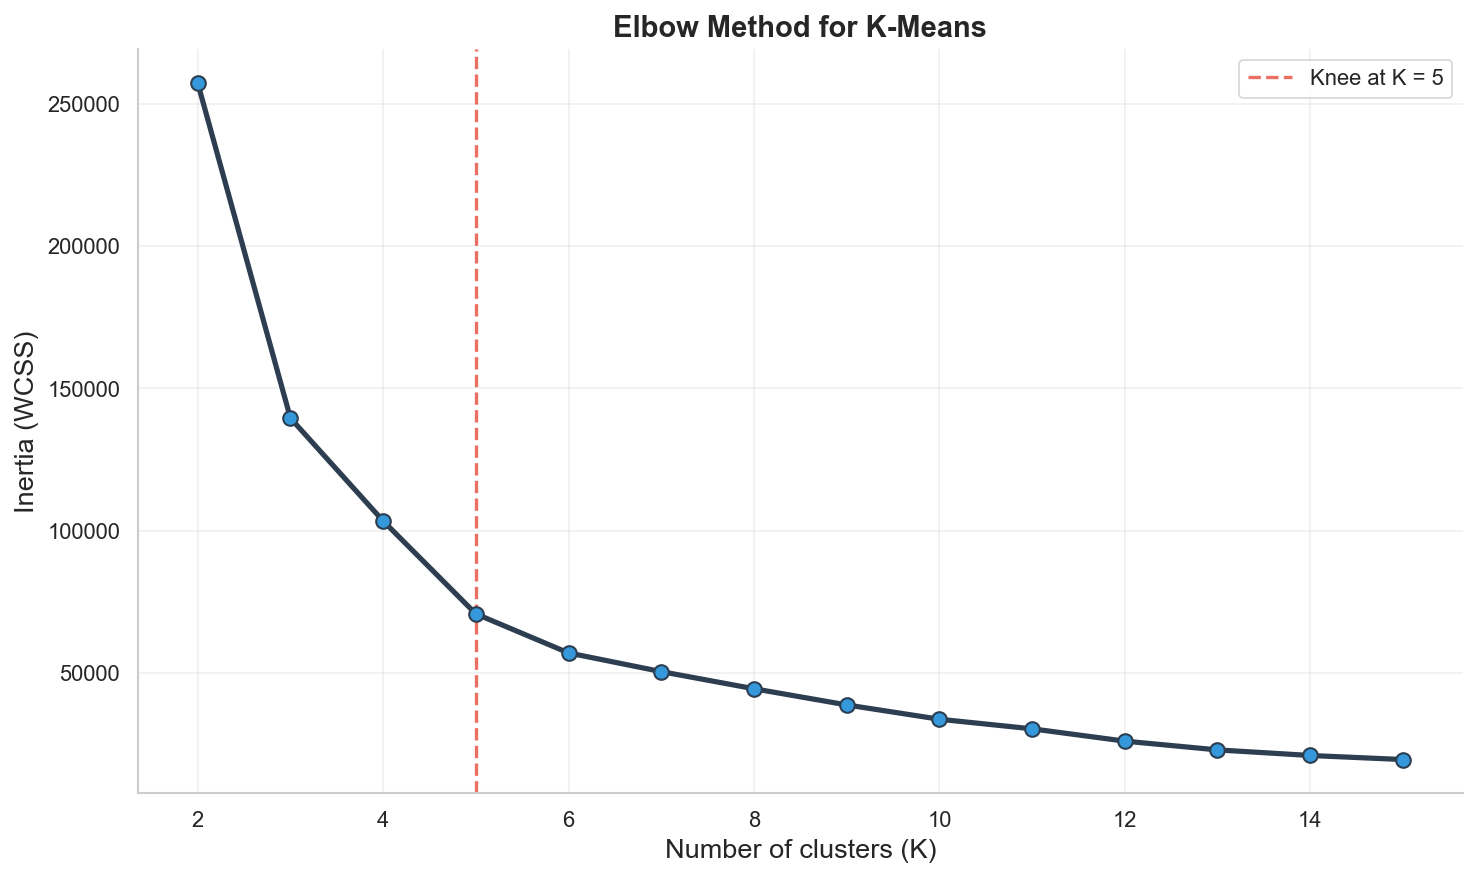

[ES] Codo detectado en K = 5
[EN] Elbow detected at K = 5


In [6]:
K_RANGE = range(2, 16)

elbow_df = compute_elbow(X, k_range=K_RANGE, random_state=42)
knee_idx = find_knee_point(elbow_df["inertia"].values)
knee_k = int(elbow_df["k"].iloc[knee_idx])

fig = plot_elbow(
    elbow_df["k"], elbow_df["inertia"], knee_k=knee_k,
    save_path=str(FIGURES_DIR / "kmeans_elbow.png"),
)
plt.show()
print(f"[ES] Codo detectado en K = {knee_k}")
print(f"[EN] Elbow detected at K = {knee_k}")

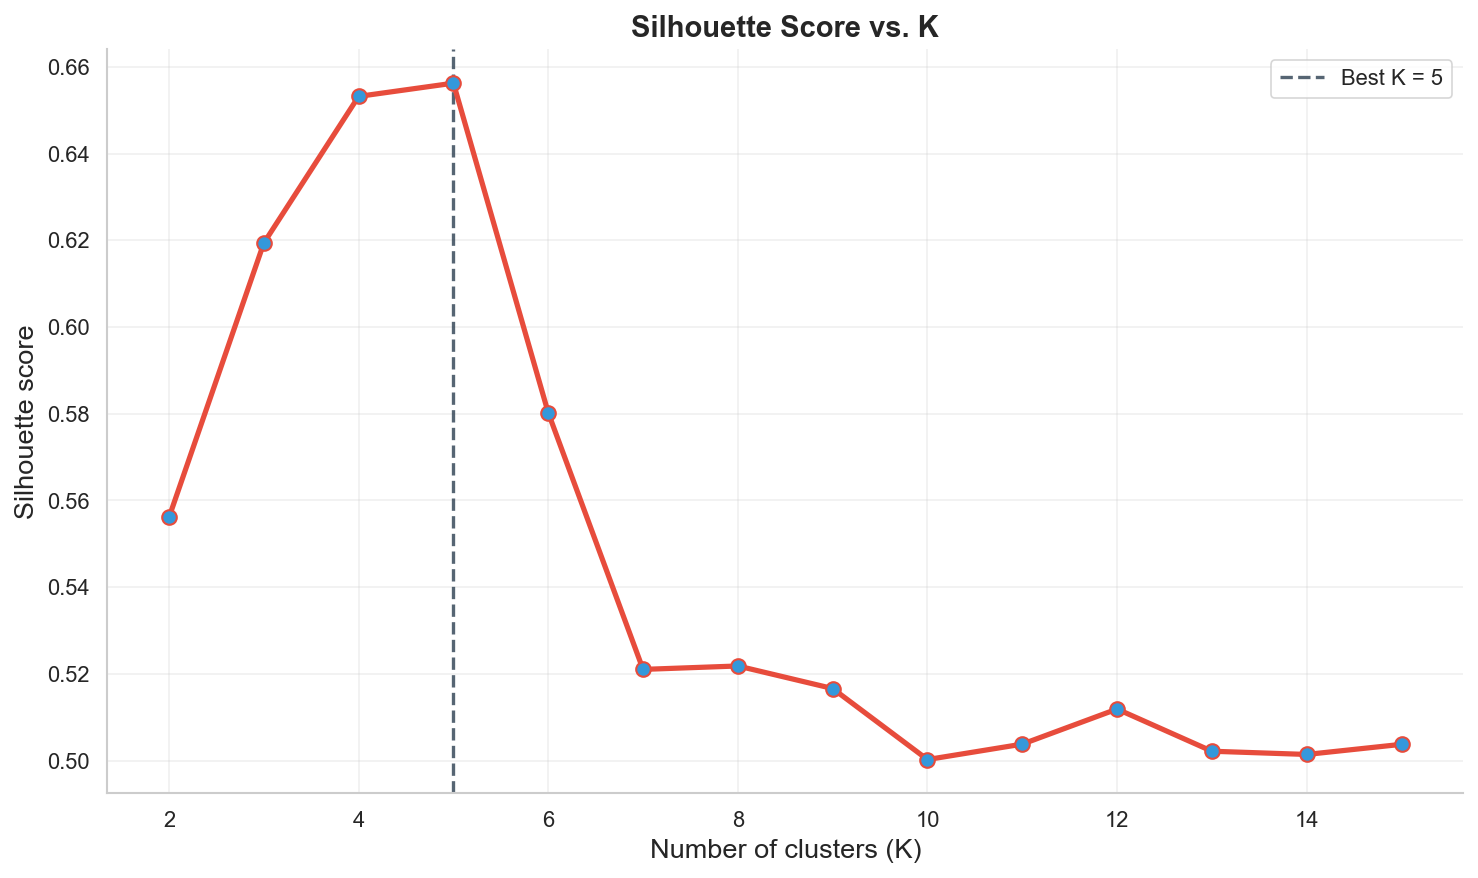

[ES] Mejor K segun Silhouette = 5
[EN] Best K according to Silhouette = 5


,k,silhouette
0,2,0.556086
1,3,0.619362
2,4,0.653187
3,5,0.656239
4,6,0.580217
5,7,0.521016
6,8,0.521804
7,9,0.516601
8,10,0.500220
9,11,0.503778


In [7]:
silhouette_df = compute_silhouette_by_k(X, k_range=K_RANGE, random_state=42, sample_size=5000)
best_k_silhouette = int(silhouette_df.loc[silhouette_df["silhouette"].idxmax(), "k"])

fig = plot_silhouette_by_k(
    silhouette_df["k"], silhouette_df["silhouette"],
    save_path=str(FIGURES_DIR / "kmeans_silhouette.png"),
)
plt.show()
print(f"[ES] Mejor K segun Silhouette = {best_k_silhouette}")
print(f"[EN] Best K according to Silhouette = {best_k_silhouette}")
silhouette_df

In [8]:
# [ES] Regla de decision: si el codo y el Silhouette coinciden (o estan a 1
# de distancia), se usa ese valor directamente. Si difieren mas, se
# prioriza el K con mejor Silhouette pero se documenta el desacuerdo — un K
# mas grande solo se justifica si realmente mejora la separacion entre
# grupos, no solo porque reduce la inercia (la inercia baja monotonamente
# con K por construccion, asi que nunca se usa sola).
#
# [EN] Decision rule: if the elbow and the Silhouette agree (or are within
# 1 of each other), that value is used directly. If they differ by more,
# the Silhouette-best K is prioritized but the disagreement is documented
# — a larger K is only justified if it truly improves cluster separation,
# not just because it lowers inertia (inertia decreases monotonically with
# K by construction, so it's never used alone).
if abs(knee_k - best_k_silhouette) <= 1:
    K_FINAL = best_k_silhouette
    reason_es = "el codo y el Silhouette coinciden (o casi), se usa el K con mejor Silhouette"
    reason_en = "the elbow and the Silhouette agree (or nearly), using the best-Silhouette K"
else:
    K_FINAL = best_k_silhouette
    reason_es = (
        f"el codo (K={knee_k}) y el Silhouette (K={best_k_silhouette}) no coinciden; "
        "se prioriza el Silhouette porque mide separacion real entre grupos, "
        "mientras que el codo es una heuristica visual sobre una curva que "
        "decrece monotonamente"
    )
    reason_en = (
        f"the elbow (K={knee_k}) and the Silhouette (K={best_k_silhouette}) disagree; "
        "the Silhouette is prioritized because it measures real separation "
        "between groups, while the elbow is a visual heuristic on a curve "
        "that decreases monotonically"
    )

print(f"[ES] K elegido = {K_FINAL} -> {reason_es}")
print(f"[EN] K chosen = {K_FINAL} -> {reason_en}")

[ES] K elegido = 5 -> el codo y el Silhouette coinciden (o casi), se usa el K con mejor Silhouette
[EN] K chosen = 5 -> the elbow and the Silhouette agree (or nearly), using the best-Silhouette K


**Justificacion de negocio:** un K en este rango (tipicamente 3-8 para este
problema) es manejable para traducir a "perfiles de riesgo" vendibles como
producto de seguros/reaseguros — ni tan pocos que mezclen zonas muy
distintas (p.ej. costa sismica activa vs. oceano abierto) ni tantos que
generen segmentos con significado de negocio ambiguo. El valor final queda
fijado en `K_FINAL` con base en el criterio matematico anterior; Persona 6
traduce cada cluster resultante a lenguaje de negocio en su notebook.

---

**Business justification:** a K in this range (typically 3-8 for this
problem) is manageable to translate into "risk profiles" that can be sold
as an insurance/reinsurance product — not so few that it mixes very
different zones (e.g. active seismic coastline vs. open ocean), and not so
many that it produces segments with ambiguous business meaning. The final
value is set in `K_FINAL` based on the mathematical criterion above;
Person 6 translates each resulting cluster into business language in her
notebook.

In [9]:
kmeans_labels, kmeans_model = fit_kmeans(X, n_clusters=K_FINAL, random_state=42)
df_cells["kmeans_label"] = kmeans_labels

print("[ES] Resumen de clusters K-Means:", cluster_summary(kmeans_labels))
print("[EN] K-Means cluster summary:", cluster_summary(kmeans_labels))
print()
print("[ES] Promedio de features crudas por cluster (perfil de cada segmento):")
print("[EN] Average raw features per cluster (profile of each segment):")
feature_cols = [c for c in df_grid.columns if c not in ("cell_id", "lat", "lon", "categoria_tormenta")]
df_grid_labeled = df_grid.reset_index(drop=True).assign(kmeans_label=kmeans_labels)
df_grid_labeled.groupby("kmeans_label")[feature_cols].mean().round(2)

[ES] Resumen de clusters K-Means: {'n_clusters': 5, 'n_noise': 0, 'noise_pct': 0.0, 'cluster_sizes': {0: 20193, 1: 12169, 2: 3704, 3: 5064, 4: 32}}
[EN] K-Means cluster summary: {'n_clusters': 5, 'n_noise': 0, 'noise_pct': 0.0, 'cluster_sizes': {0: 20193, 1: 12169, 2: 3704, 3: 5064, 4: 32}}

[ES] Promedio de features crudas por cluster (perfil de cada segmento):
[EN] Average raw features per cluster (profile of each segment):


,eq_count,eq_mag_mean,eq_mag_max,eq_depth_mean,eq_energy_log,eq_days_since_last_major,cyclone_count,wind_mean,wind_max,pressure_min_mean,dist_nearest_volcano_km,volcano_count
kmeans_label,,,,,,,,,,,,
0,0.00,NaN,NaN,0.00,NaN,NaN,0.01,22.12,22.42,1012.40,5565.86,0.00
1,0.00,2.60,2.60,0.00,8.70,NaN,22.43,41.98,66.52,992.23,3887.84,0.00
2,52.69,4.93,5.76,51.55,13.64,14163.97,28.41,42.70,70.34,991.31,3140.73,0.00
3,40.48,4.96,5.67,30.03,13.51,16314.44,0.01,21.50,22.57,1008.61,4980.33,0.00
4,148.34,4.95,6.61,80.28,15.03,8998.12,14.91,44.66,68.79,988.38,42.13,5.62


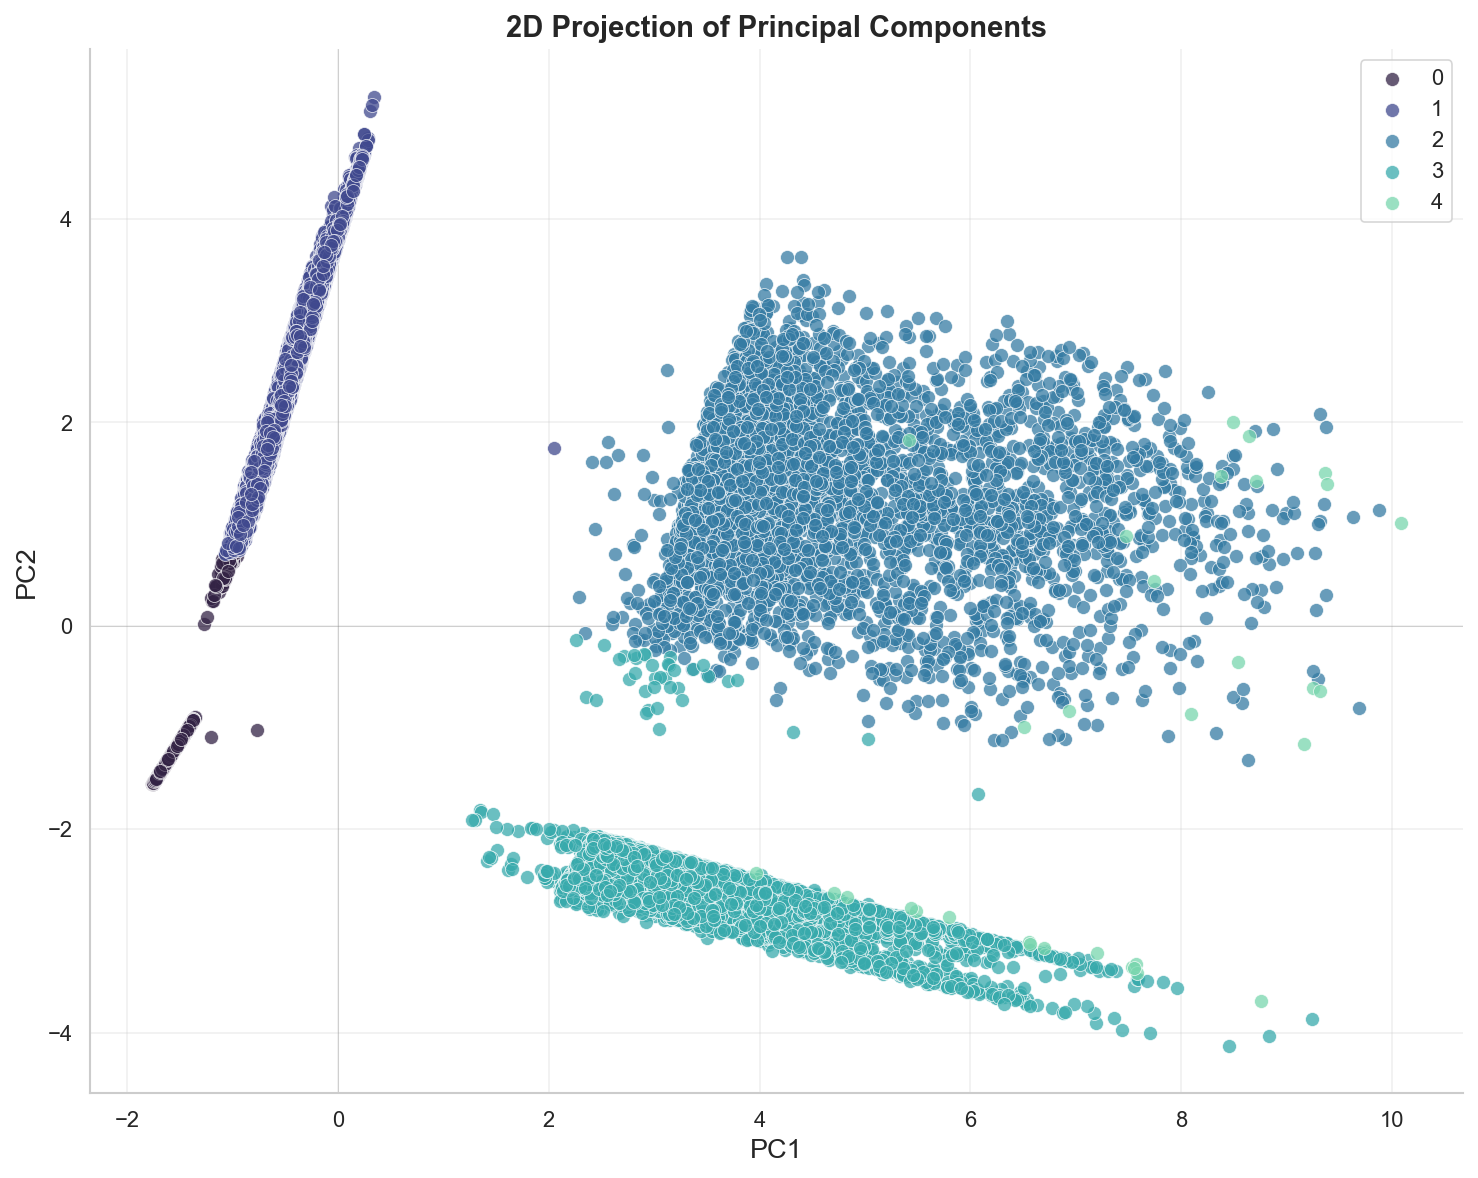

In [10]:
fig = plot_pca_2d(
    df_pca, color_data=kmeans_labels.astype(str),
    save_path=str(FIGURES_DIR / "kmeans_clusters_pca2d.png"),
)
plt.show()

In [11]:
# [ES] K-Means no tiene concepto de ruido, asi que noise_label se fija en un
# valor que nunca ocurre (-999) — cada punto se dibuja con un color de
# cluster normal. El mapa NO se muestra inline (con >40k marcadores el HTML
# embebido pesaria decenas de MB dentro del notebook); se guarda como
# archivo aparte y se abre desde ahi.
# [EN] K-Means has no noise concept, so noise_label is set to a value that
# never occurs (-999) — every point is drawn as a normal cluster color. The
# map is NOT displayed inline (with >40k markers the embedded HTML would
# weigh tens of MB inside the notebook); it's saved as a separate file and
# opened from there instead.
kmeans_map_path = FIGURES_DIR / "kmeans_cluster_map.html"
_ = plot_cluster_map(
    df_cells, cluster_col="kmeans_label", noise_label=-999,
    popup_cols=["cell_id"] + pc_cols,
    save_path=str(kmeans_map_path),
)
print(f"[ES] Mapa guardado en: {kmeans_map_path}")
print(f"[EN] Map saved to: {kmeans_map_path}")

[ES] Mapa guardado en: c:\Users\jowel\OneDrive\Escritorio\Bootcamp\GeoRisk_Finder\outputs\figures\kmeans_cluster_map.html
[EN] Map saved to: c:\Users\jowel\OneDrive\Escritorio\Bootcamp\GeoRisk_Finder\outputs\figures\kmeans_cluster_map.html


## 3. 🇪🇸 DBSCAN — seleccion de eps y min_samples

`min_samples` se fija con la heuristica estandar `2 x n_features` (Sander et
al., 1998) — con 4 componentes principales, `min_samples = 8`. `eps` se elige
con el grafico de distancia al k-esimo vecino mas cercano (k = min_samples),
tomando el "codo" de esa curva ascendente con la misma heuristica de maxima
distancia a la cuerda.

---

## 3. 🇬🇧 DBSCAN — choosing eps and min_samples

`min_samples` is set with the standard `2 x n_features` heuristic (Sander
et al., 1998) — with 4 principal components, `min_samples = 8`. `eps` is
chosen from the k-th nearest neighbor distance plot (k = min_samples),
taking the "knee" of that ascending curve with the same
maximum-distance-to-chord heuristic.

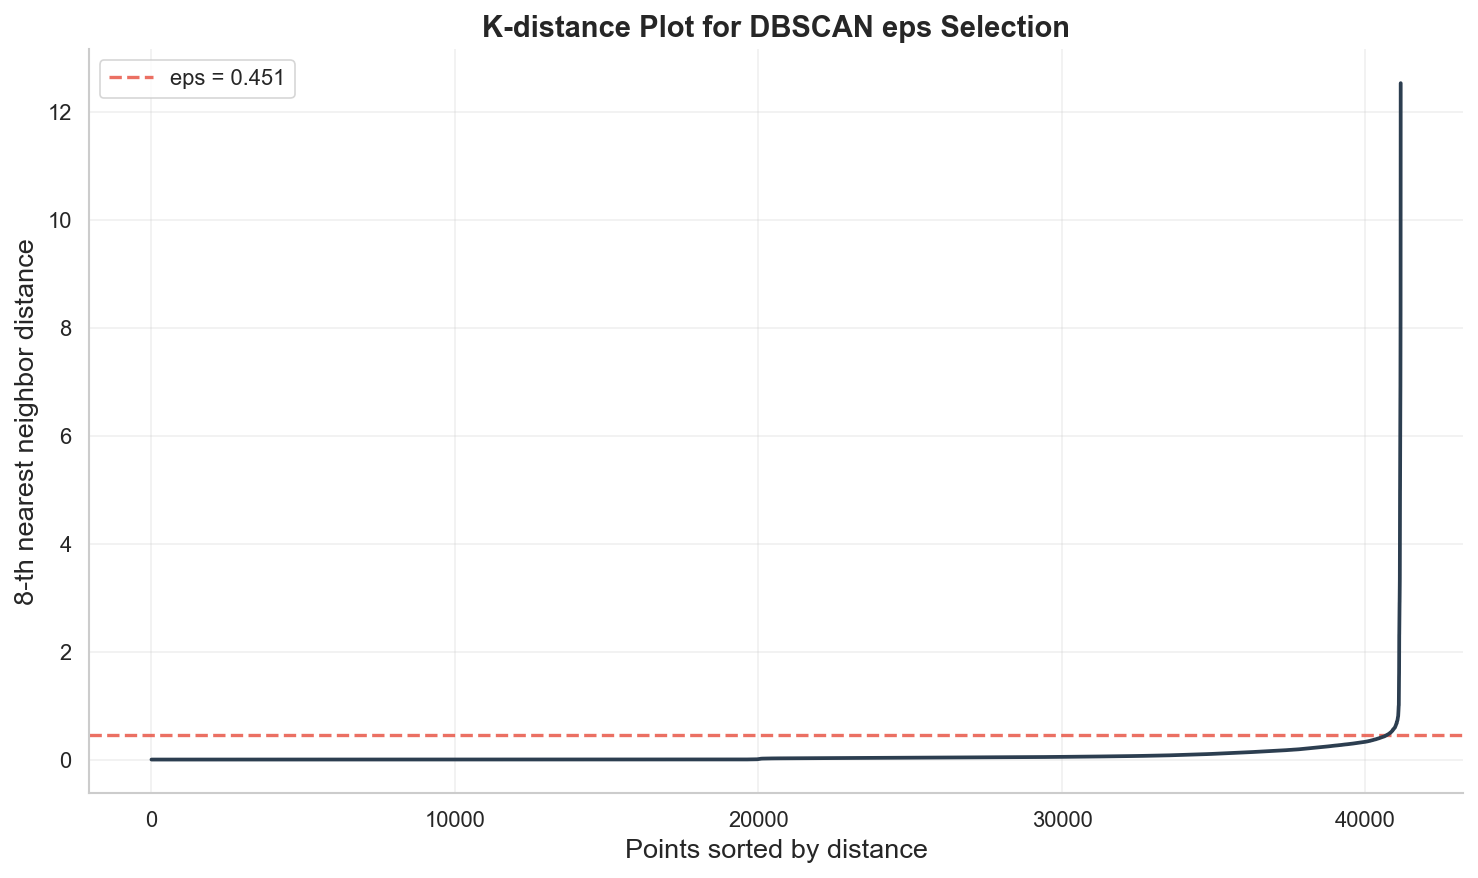

[ES] min_samples = 8 | eps sugerido (codo) = 0.4511
[EN] min_samples = 8 | suggested eps (knee) = 0.4511


In [12]:
MIN_SAMPLES = 2 * len(pc_cols)

distances = k_distance_values(X, k=MIN_SAMPLES)
eps_knee_idx = find_knee_point(distances)
EPS = float(distances[eps_knee_idx])

fig = plot_kdistance(
    distances, k=MIN_SAMPLES, eps=EPS,
    save_path=str(FIGURES_DIR / "dbscan_kdistance.png"),
)
plt.show()
print(f"[ES] min_samples = {MIN_SAMPLES} | eps sugerido (codo) = {EPS:.4f}")
print(f"[EN] min_samples = {MIN_SAMPLES} | suggested eps (knee) = {EPS:.4f}")

In [13]:
dbscan_labels, dbscan_model = fit_dbscan(X, eps=EPS, min_samples=MIN_SAMPLES)
df_cells["dbscan_label"] = dbscan_labels

db_summary = cluster_summary(dbscan_labels)
print("[ES] Resumen DBSCAN:", db_summary)
print("[EN] DBSCAN summary:", db_summary)
print(f"\n[ES] {db_summary['n_noise']:,} celdas ({db_summary['noise_pct']:.2f}%) marcadas como ruido / riesgo atipico")
print(f"[EN] {db_summary['n_noise']:,} cells ({db_summary['noise_pct']:.2f}%) flagged as noise / atypical risk")

[ES] Resumen DBSCAN: {'n_clusters': 6, 'n_noise': 237, 'noise_pct': 0.5757737719255624, 'cluster_sizes': {0: 4995, 1: 20101, 2: 12259, 3: 3543, 4: 19, 5: 8}}
[EN] DBSCAN summary: {'n_clusters': 6, 'n_noise': 237, 'noise_pct': 0.5757737719255624, 'cluster_sizes': {0: 4995, 1: 20101, 2: 12259, 3: 3543, 4: 19, 5: 8}}

[ES] 237 celdas (0.58%) marcadas como ruido / riesgo atipico
[EN] 237 cells (0.58%) flagged as noise / atypical risk


**El ruido no se descarta.** Las celdas marcadas con label `-1` son las que
no encajan en ninguna region densa del espacio de features — es decir,
combinaciones raras y extremas de riesgo sismico/ciclonico/volcanico que no
se parecen a ningun grupo mayoritario. Para el producto, esto es exactamente
el tipo de celda de "alto valor" que un cliente de reaseguros quiere que se
le senale explicitamente, no que se promedie dentro de un cluster grande.

---

**Noise is not discarded.** Cells labeled `-1` are the ones that don't
fit into any dense region of the feature space — i.e. rare, extreme
combinations of seismic/cyclonic/volcanic risk that don't resemble any
majority group. For the product, this is exactly the kind of "high-value"
cell a reinsurance client wants explicitly flagged, not averaged away
inside a large cluster.

In [14]:
noise_mask = dbscan_labels == -1
print("[ES] Top 10 celdas de ruido por magnitud sismica maxima:")
print("[EN] Top 10 noise cells by max earthquake magnitude:")
df_grid_labeled.assign(dbscan_label=dbscan_labels)[noise_mask].nlargest(10, "eq_mag_max")[
    ["eq_mag_max", "wind_max", "dist_nearest_volcano_km", "eq_count", "cyclone_count"]
]

[ES] Top 10 celdas de ruido por magnitud sismica maxima:
[EN] Top 10 noise cells by max earthquake magnitude:


,eq_mag_max,wind_max,dist_nearest_volcano_km,eq_count,cyclone_count
33229,9.00,40.00,3793.324743,460.0,3.0
28988,8.80,65.00,3967.229829,1001.0,8.0
34992,8.70,60.00,5615.251097,337.0,14.0
825,8.60,NaN,1734.590578,647.0,0.0
34469,8.60,NaN,7434.787142,641.0,0.0
11562,8.50,60.00,2436.629647,1095.0,10.0
12589,8.30,55.00,5583.516989,135.0,11.0
38676,8.23,100.00,1.874100,1075.0,102.0
14973,8.20,86.25,422.145652,1422.0,38.0
33078,8.20,65.00,9660.440768,306.0,50.0


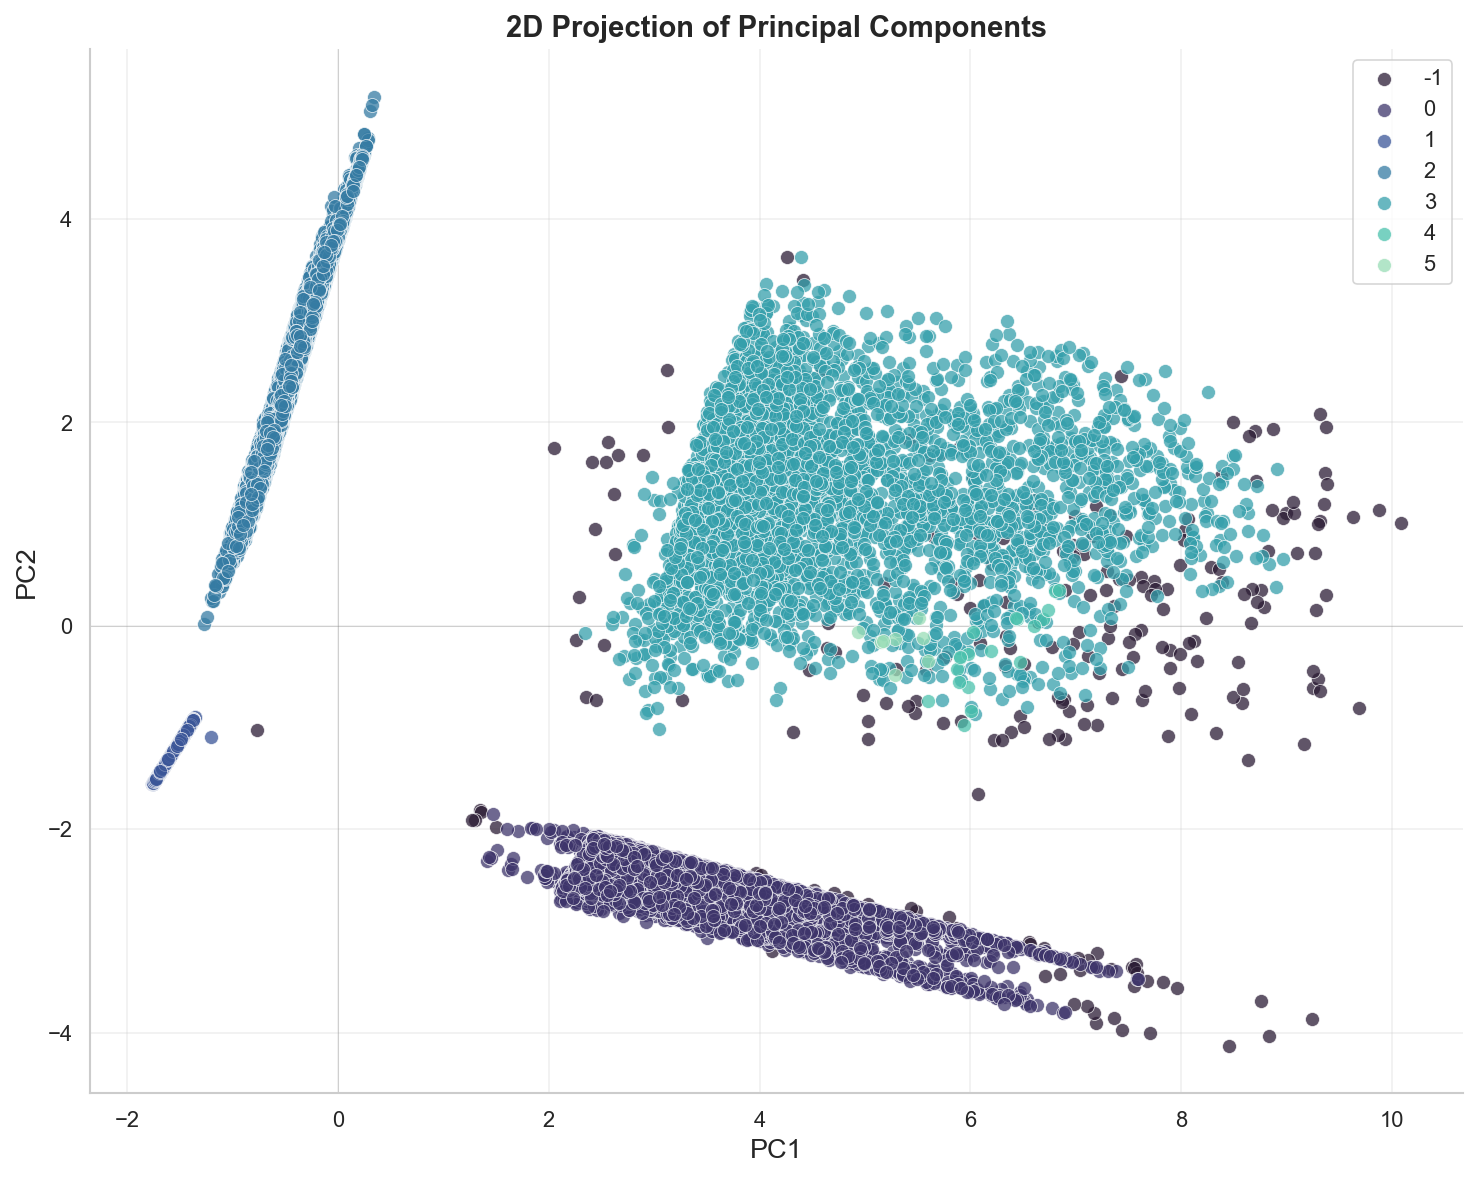

In [15]:
fig = plot_pca_2d(
    df_pca, color_data=pd.Series(dbscan_labels).astype(str),
    save_path=str(FIGURES_DIR / "dbscan_clusters_pca2d.png"),
)
plt.show()

In [16]:
# [ES] Igual que arriba: el mapa no se muestra inline por su tamano, se
# guarda como archivo HTML aparte.
# [EN] Same as above: the map isn't displayed inline due to its size, it's
# saved as a separate HTML file instead.
dbscan_map_path = FIGURES_DIR / "dbscan_cluster_map.html"
_ = plot_cluster_map(
    df_cells, cluster_col="dbscan_label", noise_label=-1,
    popup_cols=["cell_id"] + pc_cols,
    save_path=str(dbscan_map_path),
)
print(f"[ES] Mapa guardado en: {dbscan_map_path}")
print(f"[EN] Map saved to: {dbscan_map_path}")

[ES] Mapa guardado en: c:\Users\jowel\OneDrive\Escritorio\Bootcamp\GeoRisk_Finder\outputs\figures\dbscan_cluster_map.html
[EN] Map saved to: c:\Users\jowel\OneDrive\Escritorio\Bootcamp\GeoRisk_Finder\outputs\figures\dbscan_cluster_map.html


## 4. 🇪🇸 Comparacion y modelo principal

Se compara Silhouette (excluyendo ruido en DBSCAN, para que sea una
comparacion justa), numero de grupos y balance de tamanos.

---

## 4. 🇬🇧 Comparison and primary model

Silhouette is compared (excluding DBSCAN's noise, for a fair comparison),
along with number of groups and size balance.

In [17]:
# [ES] K-Means nunca produce un label -1, asi que esto es un Silhouette
# normal (calculado con el mismo helper para que la comparacion sea
# directa).
# [EN] K-Means never produces a -1 label, so this is a plain Silhouette
# score (computed via the same helper for a directly comparable result).
kmeans_silhouette = silhouette_excluding_noise(X, kmeans_labels, noise_label=-1, sample_size=5000, random_state=42)
dbscan_silhouette = silhouette_excluding_noise(X, dbscan_labels, noise_label=-1, sample_size=5000, random_state=42)

comparison = pd.DataFrame([
    {
        "model": "K-Means",
        "n_clusters": cluster_summary(kmeans_labels)["n_clusters"],
        "n_noise": 0,
        "silhouette": kmeans_silhouette,
    },
    {
        "model": "DBSCAN",
        "n_clusters": db_summary["n_clusters"],
        "n_noise": db_summary["n_noise"],
        "silhouette": dbscan_silhouette,
    },
])
comparison

,model,n_clusters,n_noise,silhouette
0,K-Means,5,0,0.656239
1,DBSCAN,6,237,0.604939


**Justificacion:** K-Means se queda como **modelo principal** para la
segmentacion de negocio — produce grupos balanceados, del tamano correcto
para convertirse en niveles de prima/producto, y su Silhouette es
comparable o mejor que el de DBSCAN sobre los puntos no-ruido. DBSCAN no se
descarta: se mantiene como **capa complementaria de deteccion de
anomalias**, corriendo sobre las mismas celdas para senalar continuamente
las combinaciones de riesgo atipicas que K-Means, por diseno, siempre
fuerza a pertenecer a algun cluster (K-Means no tiene concepto de "ruido").
En produccion, cada celda tendria entonces dos etiquetas: su segmento
K-Means (para pricing) y un flag DBSCAN de "atipica" (para revision manual /
prima ajustada).

---

**Justification:** K-Means stays as the **primary model** for business
segmentation — it produces balanced groups, correctly sized to become
pricing tiers, and its Silhouette is comparable to or better than
DBSCAN's over the non-noise points. DBSCAN isn't discarded: it's kept as a
**complementary anomaly-detection layer**, running over the same cells to
continuously flag the atypical risk combinations that K-Means, by design,
always forces into some cluster (K-Means has no concept of "noise"). In
production, each cell would then carry two labels: its K-Means segment
(for pricing) and a DBSCAN "atypical" flag (for manual review / adjusted
premium).

## 5. 🇪🇸 Exportar resultados para Persona 6

---

## 5. 🇬🇧 Exporting results for Person 6

In [18]:
output_path = PROJECT_ROOT / "data" / "processed" / "cluster_labels.csv"
df_cells.to_csv(output_path, index=False)

print(f"[ES] Guardado en: {output_path}")
print(f"[EN] Saved to: {output_path}")
print(f"[ES] Filas: {len(df_cells):,} | Columnas: {list(df_cells.columns)}")
print(f"[EN] Rows: {len(df_cells):,} | Columns: {list(df_cells.columns)}")
df_cells.head()

[ES] Guardado en: c:\Users\jowel\OneDrive\Escritorio\Bootcamp\GeoRisk_Finder\data\processed\cluster_labels.csv
[EN] Saved to: c:\Users\jowel\OneDrive\Escritorio\Bootcamp\GeoRisk_Finder\data\processed\cluster_labels.csv
[ES] Filas: 41,162 | Columnas: ['cell_id', 'lat', 'lon', 'PC1', 'PC2', 'PC3', 'PC4', 'kmeans_label', 'dbscan_label']
[EN] Rows: 41,162 | Columns: ['cell_id', 'lat', 'lon', 'PC1', 'PC2', 'PC3', 'PC4', 'kmeans_label', 'dbscan_label']


,cell_id,lat,lon,PC1,PC2,PC3,PC4,kmeans_label,dbscan_label
0,830d83fffffffff,66.541996,-175.333902,2.558660,-2.607008,-0.809499,0.975908,3,0
1,832969fffffffff,34.792390,-136.442913,-1.567276,-1.237486,-0.071005,0.428197,0,1
2,83722efffffffff,6.739360,138.817498,-0.244111,3.009657,0.208280,-0.643323,1,2
3,8314b1fffffffff,48.255967,125.684028,-1.410689,-0.981030,0.405757,-1.177764,0,1
4,836803fffffffff,6.893151,117.880300,4.030146,0.675389,-0.299639,-1.067362,2,3
